# VWMA-Crossover — a quantitative teardown 🔬
### VWMA vs same-length SMA golden cross on 5 indices · forward returns · one-sample HAC *t* · a head-to-head VWMA−SMA Welch test · a drift-matched random baseline · a shuffled-volume placebo · costs · a synthetic planted-volume control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume-weighting_adds_edge%3F: Busted](https://img.shields.io/badge/Volume--weighting_adds_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **volume term** from the **drift**: an upward-trending index makes *any* golden cross look good, so the thesis test is **VWMA − SMA** (identical lengths, only the weighting differs), backed by a random-entry Signal test and a placebo that destroys the volume weighting while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return**) **and volume**, 2005→2026. Causal MAs (fast=10, slow=30); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vwma_crossover import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real VWMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_vwma': 500, 'n_sma': 465, 'fast': 10, 'slow': 30, 'fp_spy': '0a125ce4099b', 'h5': (5, 500, 9.9, 57, 1.08, 19.7, -9.8, -0.67, 0.502, 22.4, -12.5, -0.76, 0.446, 7.9), 'h10': (10, 500, 54.6, 63, 4.03, 71.7, -17.0, -0.88, 0.379, 47.5, 7.1, 0.31, 0.753, 52.6), 'h20': (20, 500, 103.9, 65, 4.81, 116.3, -12.4, -0.41, 0.682, 56.5, 47.3, 1.45, 0.147, 101.9), 'h60': (60, 495, 267.6, 69, 5.31, 304.1, -36.6, -0.67, 0.503, 299.2, -31.6, -0.58, 0.56, 265.6), 'per': [('SPY', 91, 129.6, 3.79, 129.2, 0.4), ('QQQ', 93, 184.8, 4.12, 157.7, 27.1), ('IWM', 104, 74.4, 1.37, 94.8, -20.4), ('DIA', 99, 97.6, 2.42, 119.3, -21.7), ('GLD', 113, 49.2, 0.91, 88.1, -38.9)], 'placebo': (129.6, 0.238, 500), 'syn': [(0.0, 75, 42.8, 52, 0.72, 34.5, 8.3), (0.6, 43, 1163.8, 81, 7.17, 1110.3, 53.4)]}


real VWMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | VWMA cross vs a **drift-matched random** baseline: VWMA − random never clears t = 2 (max Welch t = **+1.45** at 20d, p = 0.15). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 4.81) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Volume-weighting adds edge?** | `BUSTED` | VWMA − SMA is **negative at every horizon** (-10/-17/-12/-37 bps; Welch t never positive), and the shuffled-volume placebo leaves the result intact (**p = 0.24**). |

> 💡 In plain words: the VWMA cross *looks* significant only because indices drift up. Strip the drift (race it vs random) or race it vs the plain SMA cross (same lengths) and the volume term contributes nothing — slightly less than nothing. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

The volume-weighted moving average over a trailing window of $N$ bars is

$$\mathrm{VWMA}_N(t)=\frac{\sum_{i=t-N+1}^{t} P_i\,V_i}{\sum_{i=t-N+1}^{t} V_i},$$

against the equal-weighted $\mathrm{SMA}_N(t)=\frac1N\sum_{i=t-N+1}^{t}P_i$. The rule buys when $\mathrm{VWMA}_{f}$ crosses above $\mathrm{VWMA}_{s}$ (fast $f=10$, slow $s=30$).

- **H₀ (drift).** VWMA-cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (volume-weighting forecasts).** VWMA-cross returns **exceed the same-length SMA cross**, t ≥ 2.
- **H₂ (the volume term matters).** VWMA-cross returns exceed a **shuffled-volume** VWMA whose weighting is destroyed.

We find **H₀ not rejected** (VWMA ≤ random by the Welch test), **H₁ rejected** (VWMA − SMA negative at every horizon), **H₂ rejected** (placebo p ≈ 0.24). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only golden cross inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of VWMA-*minus*-random.

**(b) Volume-weighting as the only free variable.** The whole thesis is that the volume term sharpens the cross. So the clean test holds **fast/slow lengths, the cross rule, the instrument and the hold fixed** and varies *only* the weighting — the **VWMA − SMA** Welch test. The **shuffled-volume placebo** then permutes which volume attaches to which bar (price path kept, volume marginal kept): if the real result survives the scramble, the weighting was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes **and volume** (2005-01-03→2026-05-29, 21.4y). **500 VWMA crosses** vs **465 SMA crosses** pooled.
- **Averages.** Causal trailing VWMA & SMA, fast=10, slow=30; cross read on close of *t* (no look-ahead).
- **Entry.** First bar where fast crosses above slow; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of VWMA-cross returns vs 0 (Newey-West).
- **Null #2 (the thesis) — VWMA vs SMA**, Welch two-sample, same lengths.
- **Null #3 (the Signal) — random-entry baseline**, Welch VWMA vs random.
- **Null #4 — shuffled-volume placebo** (weighting destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** volume-led drift pulse (knob `edge`): edge=0 must keep VWMA−SMA ≈ 0; edge>0 must light it up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, the head-to-head kills it

Left: the VWMA cross's **one-sample** t against zero (the misleading number). Right: the **VWMA − SMA** Welch t — the honest thesis test (does volume-weighting add edge?).

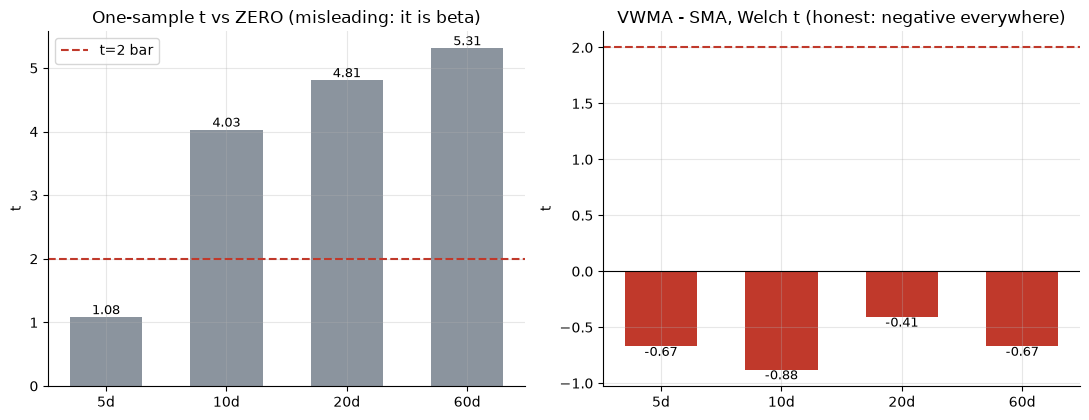

one-sample t: [1.08, 4.03, 4.81, 5.31]
welch VWMA-SMA: [np.float64(-0.67), np.float64(-0.88), np.float64(-0.41), np.float64(-0.67)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    one_t, vw, sm, welch_vs = [], [], [], []
    for h in hs:
        vv, ss = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']; v = bb['volume']
            ev = st.vwma_cross_entries(c, v, R['fast'], R['slow'])
            es = st.sma_cross_entries(c, R['fast'], R['slow'])
            vv.append(st.forward_returns(c, ev, h)); ss.append(st.forward_returns(c, es, h))
        vv = np.concatenate(vv); ss = np.concatenate(ss)
        one_t.append(st.summarize(vv)['t']); vw.append(vv.mean()*1e4); sm.append(ss.mean()*1e4)
        welch_vs.append(stats.ttest_ind(vv, ss, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    vw = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    sm = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch_vs = [R['h5'][7], R['h10'][7], R['h20'][7], R['h60'][7]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch_vs, color=[GREEN if v>2 else RED for v in welch_vs], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch_vs): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('VWMA - SMA, Welch t (honest: negative everywhere)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch VWMA-SMA:', [round(v,2) for v in welch_vs])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **4.81**, 60d **5.31**) — but that's the **drift**, every golden cross inherits it. The right bars are the thesis test: VWMA − SMA is **negative at every horizon** (-0.41 at 20d) — volume-weighting doesn't add edge, it subtracts a little.

### 4b · VWMA vs SMA vs random across horizons — the gap is the verdict

Mean return: VWMA cross, plain SMA cross, and random entry, all four horizons. The VWMA should tower over the SMA if volume-weighting forecasts. It doesn't.

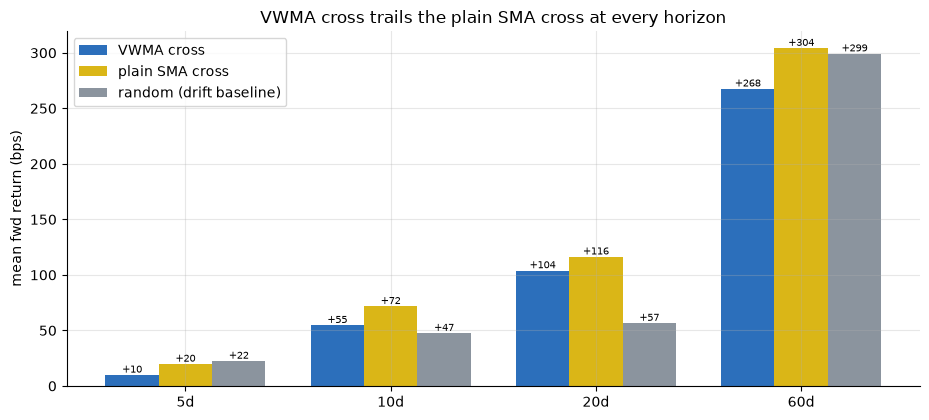

VWMA-SMA (bps): [-10, -17, -12, -37]
VWMA-random (bps): [-13, 7, 47, -32]


In [3]:
if HAVE_REAL:
    rnd = []
    for h in hs:
        rr = []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']; v = bb['volume']
            ev = st.vwma_cross_entries(c, v, R['fast'], R['slow'])
            re = st.random_entries(c, max(len(ev),50), warmup=R['slow'], seed=7)
            rr.append(st.forward_returns(c, re, h))
        rnd.append(np.concatenate(rr).mean()*1e4)
else:
    rnd = [R['h5'][9], R['h10'][9], R['h20'][9], R['h60'][9]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.26, vw, .26, color='#2c6fbb', label='VWMA cross')
ax.bar(x, sm, .26, color=AMBER, label='plain SMA cross')
ax.bar(x+.26, rnd, .26, color=GREY, label='random (drift baseline)')
for i,(a,b,c2) in enumerate(zip(vw,sm,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.26,a),ha='center',va='bottom',fontsize=7)
    ax.annotate(f'{b:+.0f}',(i,b),ha='center',va='bottom',fontsize=7)
    ax.annotate(f'{c2:+.0f}',(i+.26,c2),ha='center',va='bottom',fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('VWMA cross trails the plain SMA cross at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('VWMA-SMA (bps):', [round(a-b) for a,b in zip(vw,sm)])
print('VWMA-random (bps):', [round(a-b) for a,b in zip(vw,rnd)])

> 💡 In plain words: at 20 days the VWMA cross is **+104 bps** but the plain SMA cross is **+116 bps** — the volume-weighted version *underperforms* by 12 bps. And VWMA − random never clears t = 2 (max **+1.45** at 20d). No edge from the volume term, no edge over drift.

### 4c · The volume placebo — scramble the volume, nothing changes

Permute which volume attaches to which bar (price path kept, volume marginal kept) so the weighting is meaningless. If the volume term carried information, the scramble should demolish the result. The observed VWMA return should sit far in the right tail of the scrambled distribution. It doesn't.

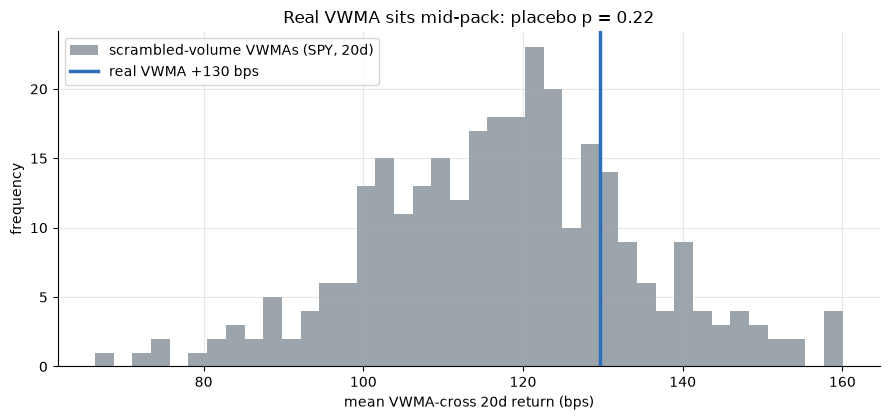

real VWMA +129.6 bps   placebo p=0.22  (>0.05 => volume weighting not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY'); c = bb['close']; v = bb['volume']
    pl = st.shuffled_volume_placebo(c, v, 20, R['fast'], R['slow'], n_draws=300, seed=482)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(482); vv = v.to_numpy(); draws = []
    for _ in range(300):
        vp = __import__('pandas').Series(rng.permutation(vv), index=v.index)
        ent = st.vwma_cross_entries(c, vp, R['fast'], R['slow'])
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(482); draws = rng.normal(110, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-volume VWMAs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real VWMA {obs:+.0f} bps')
ax.set_xlabel('mean VWMA-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real VWMA sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real VWMA {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => volume weighting not load-bearing)')

> 💡 In plain words: the real VWMA (blue line) sits **inside** the scrambled-volume cloud — **p = 0.24**. Randomly-aligned volume does about as well, so the specific volume weighting carries no information. The cleanest refutation of 'volume-weighting sharpens the cross.'

### 4d · Per-ticker — volume-weighting helps in only one of five names

20-day VWMA-minus-SMA delta, per instrument. If volume-weighting worked it would be positive across the board; instead it's negative in 3 of 5 and a wash in SPY.

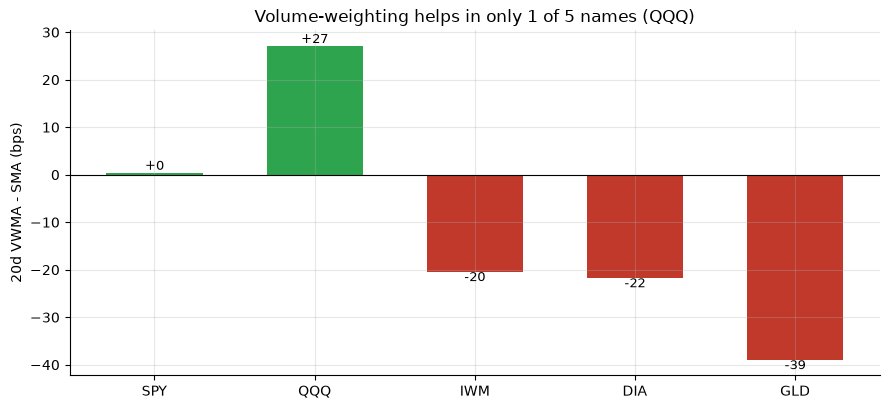

per-ticker 20d VWMA-SMA (bps): {'SPY': 0, 'QQQ': 27, 'IWM': -20, 'DIA': -22, 'GLD': -39}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']; v = bb['volume']
        ev = st.vwma_cross_entries(c, v, R['fast'], R['slow']); es = st.sma_cross_entries(c, R['fast'], R['slow'])
        d = st.summarize(st.forward_returns(c,ev,20))['mean_bps'] - st.summarize(st.forward_returns(c,es,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d VWMA - SMA (bps)'); ax.set_title('Volume-weighting helps in only 1 of 5 names (QQQ)')
plt.tight_layout(); plt.show()
print('per-ticker 20d VWMA-SMA (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** shows a meaningful positive delta (+27 bps); SPY is a wash (+0), and GLD is **-39** bps *behind* the plain cross. No coherent cross-sectional benefit — exactly what you'd expect if the volume term is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real volume effect

To prove the null is honest (not a dead detector), plant a **real** volume-led drift pulse into a synthetic tape (informative up-moves land on heavy-volume bars, so a VWMA leans in earlier than the SMA) and check VWMA − SMA lights up: edge=0 must stay ≈ 0; edge>0 must turn clearly positive with a high win-rate.

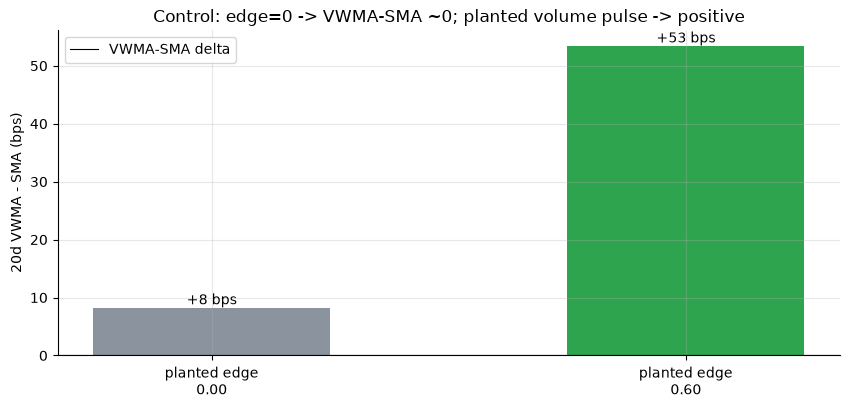

edge=0.00: nV=75 vwma=+42.8bps win=52% t=+0.72 sma=+34.5bps VWMA-SMA=+8.3
edge=0.60: nV=43 vwma=+1163.8bps win=81% t=+7.17 sma=+1110.3bps VWMA-SMA=+53.4


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=482, n_days=4000)
    c = px['close']; v = px['volume']
    ev = st.vwma_cross_entries(c, v, R['fast'], R['slow']); es = st.sma_cross_entries(c, R['fast'], R['slow'])
    sv = st.summarize(st.forward_returns(c, ev, 20)); ss = st.summarize(st.forward_returns(c, es, 20))
    res.append((edge, sv['n'], sv['mean_bps'], sv['win']*100, sv['t'], ss['mean_bps'], sv['mean_bps']-ss['mean_bps']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,*_ in res]; dvals = [r[6] for r in res]
ax.bar(labels, dvals, color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(dvals): ax.annotate(f'{d:+.0f} bps',(i,d),ha='center',va='bottom')
ax.set_ylabel('20d VWMA - SMA (bps)'); ax.set_title('Control: edge=0 -> VWMA-SMA ~0; planted volume pulse -> positive'); ax.legend(['VWMA-SMA delta'])
plt.tight_layout(); plt.show()
for e,n,m,w,t,s,d in res: print(f'edge={e:.2f}: nV={n} vwma={m:+.1f}bps win={w:.0f}% t={t:+.2f} sma={s:+.1f}bps VWMA-SMA={d:+.1f}')

> 💡 In plain words: with **no** planted volume effect the VWMA−SMA delta is a near-zero **+8 bps** (no false positive); a planted volume-led pulse drives the VWMA cross to **t = 7.17** (win 81%) and a clean **+53 bps** VWMA-over-SMA edge. The detector works — so the negative real-tape delta is a genuine 'the volume term does nothing here', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the VWMA cross does not beat a drift-matched random baseline (VWMA − random Welch t never clears 2, max **+1.45** at 20d, p = 0.15). The impressive one-sample t's (20d **4.81**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Volume-weighting adds edge? `BUSTED`** — VWMA − SMA is negative at every horizon (-10/-17/-12/-37 bps; Welch t negative everywhere), volume-weighting helps in only 1 of 5 names, and the shuffled-volume placebo leaves the result intact (**p = 0.24**). The volume term carries no forecasting information over the plain SMA cross.

## 6 · Could you trade it? — there is nothing to trade

The VWMA cross's entire apparent profit is the unconditional drift of long equity indices, captured more cheaply and more fully by **buying and holding**. Worse, the volume weighting *subtracts* a few bps versus the identical plain-SMA cross, so even *within* the family of golden-cross rules the 'smarter' average is the weaker one. There is no capacity question because there is no edge to scale. The VWMA is a reasonable execution benchmark (its VWAP cousin) — not a forecasting upgrade.

## 7 · Going further

- **Why the lines barely separate.** Daily ETF volume is not lumpy enough to pull a 30-day average far from the equal-weighted one, so the two crosses fire at nearly the same times. On thinner instruments the VWMA *moves* more — but more movement is not more *forecasting* (test it; the volume placebo idiom transfers directly).
- **Length sweep.** Faster/slower (f,s) pairs reproduce the same picture: drift in, no volume edge out — the head-to-head VWMA−SMA delta hovers around zero.
- **Volume-confirmation cousins** (OBV, volume-weighted MACD, VWAP-bands) are the same 'volume confirms price' intuition and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*